# RNN Forecasting Pipeline

This notebook mirrors the same parquet input, feature set, target construction, chronological splitting, and evaluation philosophy used in `LSTM.ipynb`, but swaps the LSTM layer for a vanilla PyTorch RNN. The input remains a short local sequence of engineered market-state snapshots, and the output is the 5-second-ahead return for the final timestep in each window.

In [13]:
# ==========================================
# 1. Imports
# ==========================================
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import RobustScaler

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

plt.style.use("seaborn-v0_8-whitegrid")

In [14]:
# ==========================================
# 2. Config
# ==========================================
CONFIG = {
    "data_path": "../data/LSTM_DATA_WITH_PRICE.parquet",
    "target_candidates": ["Target_5s_Return", "future_return_5s"],
    "seed": 42,
    "test_quantile": 0.85,
    "val_quantile_within_base": 0.85,
    "seq_len": 60,
    "clip_val": 10.0,
    "batch_size": 1024,
    "epochs": 50,
    "patience": 8,
    "learning_rate": 1e-3,
    "weight_decay": 1e-5,
    "grad_clip": 1.0,
    "hidden_size": 64,
    "num_layers": 2,
    "dropout": 0.20,
    "rnn_nonlinearity": "tanh",
    "taker_fee_rate": 0.072,
    "upper_quantile": 0.90,
    "lower_quantile": 0.10,
    "direction_epsilon": 1e-5,
    "model_path": "../models/best_alpha_rnn.pth",
}


def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    if hasattr(torch.backends, "cudnn"):
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    if hasattr(torch, "use_deterministic_algorithms"):
        torch.use_deterministic_algorithms(True, warn_only=True)


set_seed(CONFIG["seed"])

if hasattr(torch, "set_float32_matmul_precision"):
    torch.set_float32_matmul_precision("high")

mps_available = hasattr(torch.backends, "mps") and torch.backends.mps.is_available()
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if mps_available else "cpu")

print(f"Using device: {device}")
print(f"Checkpoint file: {Path(CONFIG['model_path']).resolve()}")


Using device: mps
Checkpoint file: /Users/moryshi/Projects/fintech/540 Machine Learning/PolyMarket analysis - inverse reinforcement learning/models/best_alpha_rnn.pth


In [15]:
# ==========================================
# 3. Data loading
# Same parquet source and backtest metadata logic as LSTM.ipynb.
# ==========================================
data = pd.read_parquet(CONFIG["data_path"]).copy()

required_cols = {"slug", "timestamp"}
missing_required = sorted(required_cols.difference(data.columns))
if missing_required:
    raise KeyError(f"Missing required columns: {missing_required}")

TARGET_COL = next((col for col in CONFIG["target_candidates"] if col in data.columns), None)
if TARGET_COL is None:
    raise KeyError(f"Could not find target column. Tried: {CONFIG['target_candidates']}")

data["timestamp"] = pd.to_datetime(data["timestamp"])
data = data.sort_values(["timestamp", "slug"]).reset_index(drop=True)

execution_price_candidates = [
    "execution_price",
    "Up_Mid_Price",
    "price",
    "Up_trade_close",
    "Up_micro_price",
]
execution_price_col = next((col for col in execution_price_candidates if col in data.columns), None)
if execution_price_col is None:
    print(
        "⚠️ No execution price column found. Backtest metadata will keep an execution_price field, but values will be NaN until ../data/LSTM_DATA_WITH_PRICE.parquet includes price data."
    )
else:
    print(f"💵 execution_price source column: {execution_price_col}")

meta_cols = ["slug", "timestamp", TARGET_COL]
if execution_price_col is not None:
    meta_cols.append(execution_price_col)
feature_cols = [col for col in data.columns if col not in meta_cols]

if not feature_cols:
    raise ValueError("No feature columns found after excluding slug, timestamp, target, and execution price.")

non_numeric_features = data[feature_cols].select_dtypes(exclude=[np.number]).columns.tolist()
if non_numeric_features:
    raise TypeError(f"All RNN features must be numeric. Found: {non_numeric_features[:10]}")

missing_model_rows = int(data[feature_cols + [TARGET_COL]].isna().any(axis=1).sum())
if missing_model_rows:
    raise ValueError(
        f"Found {missing_model_rows} rows with missing features or target in the parquet data."
    )

print(f"Loaded shape: {data.shape}")
print(f"Target column: {TARGET_COL}")
print(f"Feature count: {len(feature_cols)}")
print(f"Unique contracts: {data['slug'].nunique()}")
print(f"Timestamp range: {data['timestamp'].min()} -> {data['timestamp'].max()}")

preview_cols = ["slug", "timestamp", TARGET_COL]
if execution_price_col is not None:
    preview_cols.append(execution_price_col)
preview_cols += feature_cols[:5]
print(data[preview_cols].head())


💵 execution_price source column: execution_price
Loaded shape: (450747, 25)
Target column: Target_5s_Return
Feature count: 21
Unique contracts: 657
Timestamp range: 2025-12-01 06:01:31+00:00 -> 2025-12-15 03:14:24+00:00
                        slug                 timestamp  Target_5s_Return  \
0  btc-updown-15m-1764568800 2025-12-01 06:01:31+00:00          0.062893   
1  btc-updown-15m-1764568800 2025-12-01 06:01:32+00:00          0.037037   
2  btc-updown-15m-1764568800 2025-12-01 06:01:33+00:00          0.024540   
3  btc-updown-15m-1764568800 2025-12-01 06:01:34+00:00          0.000000   
4  btc-updown-15m-1764568800 2025-12-01 06:01:35+00:00          0.018293   

   execution_price   moneyness  time_to_expiry  Micro_Price_Imbalance  \
0            0.795  140.658783           809.0              -0.001939   
1            0.810  140.658783           808.0              -0.002684   
2            0.815  145.819987           807.0              -0.002711   
3            0.815  146.008138 

In [16]:
# ==========================================
# 4. Chronological split
# Keep the same split philosophy as the LSTM notebook:
# - global sort by timestamp
# - latest 15% stays as sealed test data
# - validation comes from the later part of the earlier base data
# ==========================================
test_cutoff = data["timestamp"].quantile(CONFIG["test_quantile"])

df_base = data[data["timestamp"] <= test_cutoff].copy()
df_test = data[data["timestamp"] > test_cutoff].copy()

val_cutoff = df_base["timestamp"].quantile(CONFIG["val_quantile_within_base"])
df_train = df_base[df_base["timestamp"] <= val_cutoff].copy()
df_val = df_base[df_base["timestamp"] > val_cutoff].copy()

split_frames = {
    "train": df_train,
    "val": df_val,
    "test": df_test,
}

for split_name, frame in split_frames.items():
    if frame.empty:
        raise ValueError(f"{split_name} split is empty. Adjust the time split configuration.")

print(f"Base size (train + val): {len(df_base):,}")
print(f"Train size: {len(df_train):,}")
print(f"Val size:   {len(df_val):,}")
print(f"Test size:  {len(df_test):,}")
print(f"Train range: {df_train['timestamp'].min()} -> {df_train['timestamp'].max()}")
print(f"Val range:   {df_val['timestamp'].min()} -> {df_val['timestamp'].max()}")
print(f"Test range:  {df_test['timestamp'].min()} -> {df_test['timestamp'].max()}")

Base size (train + val): 383,135
Train size: 325,664
Val size:   57,471
Test size:  67,612
Train range: 2025-12-01 06:01:31+00:00 -> 2025-12-12 11:37:08+00:00
Val range:   2025-12-12 11:37:09+00:00 -> 2025-12-13 17:02:57+00:00
Test range:  2025-12-13 17:02:58+00:00 -> 2025-12-15 03:14:24+00:00


In [17]:
# ==========================================
# 5. Scaling
# Fit the scaler on train only, then transform val/test.
# ==========================================
scaler = RobustScaler()
CLIP_VAL = CONFIG["clip_val"]

df_train.loc[:, feature_cols] = scaler.fit_transform(df_train[feature_cols])
df_val.loc[:, feature_cols] = scaler.transform(df_val[feature_cols])
df_test.loc[:, feature_cols] = scaler.transform(df_test[feature_cols])

for frame in (df_train, df_val, df_test):
    frame.loc[:, feature_cols] = np.clip(frame[feature_cols], -CLIP_VAL, CLIP_VAL)

print("Scaler fit on training set only, then applied to validation and test.")

Scaler fit on training set only, then applied to validation and test.


In [18]:
# ==========================================
# 6. Sequence creation
# Same sequence framing as the LSTM notebook:
# for each contract (slug), build rolling windows and use the
# target from the final timestep in the window.
# ==========================================
def create_rnn_sequences(
    df,
    feature_cols,
    target_col="Target_5s_Return",
    seq_len=60,
    execution_price_col=None,
):
    X_list, y_list = [], []
    meta_rows = []

    grouped = df.groupby("slug", sort=False)
    print(f"Building {seq_len}-step sequences across {len(grouped)} contracts...")

    for slug, group in tqdm(grouped, leave=False):
        group = group.sort_values("timestamp").reset_index(drop=True)

        if len(group) < seq_len:
            continue

        features_np = group[feature_cols].to_numpy(dtype=np.float32)
        targets_np = group[target_col].to_numpy(dtype=np.float32)
        timestamps_np = group["timestamp"].to_numpy()
        if execution_price_col is not None and execution_price_col in group.columns:
            execution_prices_np = pd.to_numeric(group[execution_price_col], errors="coerce").to_numpy(dtype=np.float32)
        else:
            execution_prices_np = np.full(len(group), np.nan, dtype=np.float32)

        for i in range(len(group) - seq_len + 1):
            end_idx = i + seq_len - 1
            X_list.append(features_np[i : i + seq_len])
            y_list.append(targets_np[end_idx])
            meta_rows.append(
                {
                    "slug": slug,
                    "timestamp": timestamps_np[end_idx],
                    "execution_price": execution_prices_np[end_idx],
                }
            )

    X_tensor = np.asarray(X_list, dtype=np.float32)
    y_tensor = np.asarray(y_list, dtype=np.float32)
    meta_df = pd.DataFrame(meta_rows)

    print(f"X shape: {X_tensor.shape}")
    print(f"y shape: {y_tensor.shape}")
    print(f"Metadata shape: {meta_df.shape}")
    return X_tensor, y_tensor, meta_df


X_train_np, y_train_np, meta_train = create_rnn_sequences(
    df_train,
    feature_cols,
    target_col=TARGET_COL,
    seq_len=CONFIG["seq_len"],
    execution_price_col=execution_price_col,
)
X_val_np, y_val_np, meta_val = create_rnn_sequences(
    df_val,
    feature_cols,
    target_col=TARGET_COL,
    seq_len=CONFIG["seq_len"],
    execution_price_col=execution_price_col,
)
X_test_np, y_test_np, meta_test = create_rnn_sequences(
    df_test,
    feature_cols,
    target_col=TARGET_COL,
    seq_len=CONFIG["seq_len"],
    execution_price_col=execution_price_col,
)


Building 60-step sequences across 480 contracts...


X shape: (297344, 60, 21)
y shape: (297344,)
Metadata shape: (297344, 3)
Building 60-step sequences across 83 contracts...


X shape: (52574, 60, 21)
y shape: (52574,)
Metadata shape: (52574, 3)
Building 60-step sequences across 96 contracts...


X shape: (61948, 60, 21)
y shape: (61948,)
Metadata shape: (61948, 3)


In [19]:
# ==========================================
# 7. Dataset and DataLoader
# Train is shuffled. Validation and test stay in order.
# ==========================================
class QuantSequenceDataset(Dataset):
    def __init__(self, X_tensor, y_tensor):
        self.X = torch.tensor(X_tensor, dtype=torch.float32)
        self.y = torch.tensor(y_tensor, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_dataset = QuantSequenceDataset(X_train_np, y_train_np)
val_dataset = QuantSequenceDataset(X_val_np, y_val_np)
test_dataset = QuantSequenceDataset(X_test_np, y_test_np)

loader_kwargs = {
    "batch_size": CONFIG["batch_size"],
    "num_workers": 0,
    "pin_memory": torch.cuda.is_available(),
}

train_generator = torch.Generator()
train_generator.manual_seed(CONFIG["seed"])

train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    drop_last=True,
    generator=train_generator,
    **loader_kwargs,
)
val_loader = DataLoader(
    val_dataset,
    shuffle=False,
    drop_last=False,
    **loader_kwargs,
)
test_loader = DataLoader(
    test_dataset,
    shuffle=False,
    drop_last=False,
    **loader_kwargs,
)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")

Train batches: 290
Val batches:   52
Test batches:  61


In [20]:
# ==========================================
# 8. RNN model
# Replace LSTM with a vanilla recurrent network while keeping
# the same "use last timestep to predict next 5s return" logic.
# ==========================================
class AlphaRNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout_prob, nonlinearity="tanh"):
        super().__init__()
        rnn_dropout = dropout_prob if num_layers > 1 else 0.0
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            nonlinearity=nonlinearity,
            batch_first=True,
            dropout=rnn_dropout,
        )
        self.dropout = nn.Dropout(dropout_prob)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        rnn_out, _ = self.rnn(x)
        last_step_out = rnn_out[:, -1, :]
        out = self.dropout(last_step_out)
        return self.fc(out).squeeze(-1)


model = AlphaRNN(
    input_size=len(feature_cols),
    hidden_size=CONFIG["hidden_size"],
    num_layers=CONFIG["num_layers"],
    dropout_prob=CONFIG["dropout"],
    nonlinearity=CONFIG["rnn_nonlinearity"],
).to(device)

criterion = nn.L1Loss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CONFIG["learning_rate"],
    weight_decay=CONFIG["weight_decay"],
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2,
    min_lr=1e-5,
)

print(model)

AlphaRNN(
  (rnn): RNN(21, 64, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


In [21]:
# ==========================================
# 9. Training
# Early stopping uses validation Rank IC so results remain
# directly comparable with the LSTM notebook.
# ==========================================
def safe_pearson_ic(preds, targets):
    try:
        value, _ = pearsonr(preds, targets)
    except Exception:
        value = np.nan
    return 0.0 if np.isnan(value) else float(value)


def safe_rank_ic(preds, targets):
    try:
        value, _ = spearmanr(preds, targets)
    except Exception:
        value = np.nan
    return 0.0 if np.isnan(value) else float(value)


def run_epoch(model, loader, criterion, optimizer=None, desc=None):
    is_train = optimizer is not None
    model.train(is_train)

    running_loss = 0.0
    all_preds = []
    all_targets = []

    context = torch.enable_grad() if is_train else torch.no_grad()
    with context:
        for X_batch, y_batch in tqdm(loader, desc=desc, leave=False):
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            if is_train:
                optimizer.zero_grad(set_to_none=True)

            preds = model(X_batch)
            loss = criterion(preds, y_batch)

            if is_train:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), CONFIG["grad_clip"])
                optimizer.step()

            running_loss += loss.item() * X_batch.size(0)
            all_preds.append(preds.detach().cpu().numpy())
            all_targets.append(y_batch.detach().cpu().numpy())

    avg_loss = running_loss / len(loader.dataset)
    preds_np = np.concatenate(all_preds)
    targets_np = np.concatenate(all_targets)
    return avg_loss, preds_np, targets_np


history = {
    "train_loss": [],
    "val_loss": [],
    "val_rank_ic": [],
    "val_pearson_ic": [],
    "lr": [],
}

best_val_ic = -np.inf
best_val_loss = np.inf
best_epoch = -1
patience_counter = 0

for epoch in range(1, CONFIG["epochs"] + 1):
    train_loss, _, _ = run_epoch(
        model,
        train_loader,
        criterion,
        optimizer=optimizer,
        desc=f"Epoch {epoch}/{CONFIG['epochs']} [Train]",
    )

    val_loss, val_preds, val_targets = run_epoch(
        model,
        val_loader,
        criterion,
        optimizer=None,
        desc=f"Epoch {epoch}/{CONFIG['epochs']} [Val]",
    )

    val_rank_ic = safe_rank_ic(val_preds, val_targets)
    val_pearson_ic = safe_pearson_ic(val_preds, val_targets)
    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]["lr"]
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_rank_ic"].append(val_rank_ic)
    history["val_pearson_ic"].append(val_pearson_ic)
    history["lr"].append(current_lr)

    print(
        f"Epoch {epoch:02d} | "
        f"Train MAE: {train_loss:.6f} | "
        f"Val MAE: {val_loss:.6f} | "
        f"Val Rank IC: {val_rank_ic:.4f} | "
        f"Val Pearson IC: {val_pearson_ic:.4f} | "
        f"LR: {current_lr:.2e}"
    )

    improved = (val_rank_ic > best_val_ic + 1e-6) or (
        np.isclose(val_rank_ic, best_val_ic, atol=1e-6) and val_loss < best_val_loss
    )

    if improved:
        best_val_ic = val_rank_ic
        best_val_loss = val_loss
        best_epoch = epoch
        patience_counter = 0
        torch.save(model.state_dict(), CONFIG["model_path"])
        print(f"  Saved new best model to {CONFIG['model_path']}")
    else:
        patience_counter += 1
        print(f"  Early stopping counter: {patience_counter}/{CONFIG['patience']}")

    if patience_counter >= CONFIG["patience"]:
        print(f"Stopping early at epoch {epoch}. Best epoch: {best_epoch}")
        break

Epoch 01 | Train MAE: 0.080444 | Val MAE: 0.062361 | Val Rank IC: 0.1784 | Val Pearson IC: 0.0564 | LR: 1.00e-03
  Saved new best model to ../models/best_alpha_rnn.pth


Epoch 02 | Train MAE: 0.071288 | Val MAE: 0.062501 | Val Rank IC: 0.1723 | Val Pearson IC: 0.0566 | LR: 1.00e-03
  Early stopping counter: 1/8


Epoch 03 | Train MAE: 0.071197 | Val MAE: 0.062306 | Val Rank IC: 0.1772 | Val Pearson IC: 0.0611 | LR: 1.00e-03
  Early stopping counter: 2/8


Epoch 04 | Train MAE: 0.071184 | Val MAE: 0.062329 | Val Rank IC: 0.1822 | Val Pearson IC: 0.0609 | LR: 1.00e-03
  Saved new best model to ../models/best_alpha_rnn.pth


Epoch 05 | Train MAE: 0.071186 | Val MAE: 0.062369 | Val Rank IC: 0.1757 | Val Pearson IC: 0.0606 | LR: 1.00e-03
  Early stopping counter: 1/8


...

Epoch 24 | Train MAE: 0.070836 | Val MAE: 0.062389 | Val Rank IC: 0.1876 | Val Pearson IC: 0.0645 | LR: 1.25e-04
  Early stopping counter: 4/8


Epoch 25 | Train MAE: 0.070829 | Val MAE: 0.062134 | Val Rank IC: 0.1883 | Val Pearson IC: 0.0659 | LR: 1.25e-04
  Early stopping counter: 5/8


Epoch 26 | Train MAE: 0.070792 | Val MAE: 0.062219 | Val Rank IC: 0.1929 | Val Pearson IC: 0.0620 | LR: 1.25e-04
  Early stopping counter: 6/8


Epoch 27 | Train MAE: 0.070811 | Val MAE: 0.062121 | Val Rank IC: 0.1930 | Val Pearson IC: 0.0665 | LR: 1.25e-04
  Early stopping counter: 7/8


Epoch 28 | Train MAE: 0.070769 | Val MAE: 0.062267 | Val Rank IC: 0.1956 | Val Pearson IC: 0.0613 | LR: 1.25e-04
  Early stopping counter: 8/8
Stopping early at epoch 28. Best epoch: 20


In [22]:
# ==========================================
# 10. Evaluation
# Standard regression metrics plus finance-oriented ICs.
# ==========================================
best_model = AlphaRNN(
    input_size=len(feature_cols),
    hidden_size=CONFIG["hidden_size"],
    num_layers=CONFIG["num_layers"],
    dropout_prob=CONFIG["dropout"],
    nonlinearity=CONFIG["rnn_nonlinearity"],
).to(device)
best_model.load_state_dict(torch.load(CONFIG["model_path"], map_location=device))
best_model.eval()


def regression_report(targets, preds, split_name):
    rmse = np.sqrt(mean_squared_error(targets, preds))
    mae = mean_absolute_error(targets, preds)
    r2 = r2_score(targets, preds)
    pearson_ic = safe_pearson_ic(preds, targets)
    rank_ic = safe_rank_ic(preds, targets)

    valid_idx = np.abs(targets) > CONFIG["direction_epsilon"]
    directional_accuracy = (
        np.mean(np.sign(preds[valid_idx]) == np.sign(targets[valid_idx]))
        if valid_idx.any()
        else np.nan
    )

    metrics = {
        "split": split_name,
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
        "pearson_ic": pearson_ic,
        "rank_ic": rank_ic,
        "directional_accuracy": directional_accuracy,
    }

    print()
    print("=" * 60)
    print(f"{split_name} metrics")
    print("=" * 60)
    print(f"RMSE:                 {rmse:.6f}")
    print(f"MAE:                  {mae:.6f}")
    print(f"R^2:                  {r2:.6f}")
    print(f"Pearson IC:           {pearson_ic:.4f}")
    print(f"Rank IC:              {rank_ic:.4f}")
    print(f"Directional accuracy: {directional_accuracy:.2%}")
    return metrics


val_loss, val_preds, val_targets = run_epoch(
    best_model,
    val_loader,
    criterion,
    optimizer=None,
    desc="[Val Inference]",
)
test_loss, test_preds, test_targets = run_epoch(
    best_model,
    test_loader,
    criterion,
    optimizer=None,
    desc="[Test Inference]",
)

all_val_preds = val_preds.tolist()
all_val_targets = val_targets.tolist()
all_test_preds = test_preds.tolist()
all_test_targets = test_targets.tolist()

val_results_df = meta_val.copy()
val_results_df["pred_signal"] = np.asarray(val_preds, dtype=np.float32)
val_results_df["future_return"] = np.asarray(val_targets, dtype=np.float32)
val_results_df = val_results_df.sort_values(["timestamp", "slug"]).reset_index(drop=True)

test_results_df = meta_test.copy()
test_results_df["pred_signal"] = np.asarray(test_preds, dtype=np.float32)
test_results_df["future_return"] = np.asarray(test_targets, dtype=np.float32)
raw_test_results_are_chronological = test_results_df["timestamp"].is_monotonic_increasing
test_results_df = test_results_df.sort_values(["timestamp", "slug"]).reset_index(drop=True)

print(f"Raw sequence output already chronological: {raw_test_results_are_chronological}")
if test_results_df["execution_price"].isna().all():
    print("⚠️ execution_price is all NaN in test_results_df.")
else:
    print(f"💵 execution_price non-null samples: {test_results_df['execution_price'].notna().sum()} / {len(test_results_df)}")

val_metrics = regression_report(val_targets, val_preds, "Validation")
test_metrics = regression_report(test_targets, test_preds, "Test")

metrics_df = pd.DataFrame([val_metrics, test_metrics])
metrics_df


/var/folders/j4/kwkcy_yx4s5fg992bwd59h140000gn/T/ipykernel_89657/1145403653.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_model.load_state_dict(torch.load(CONFIG

Raw sequence output already chronological: True
💵 execution_price non-null samples: 61948 / 61948

Validation metrics
RMSE:                 0.186784
MAE:                  0.062198
R^2:                  0.004331
Pearson IC:           0.0663
Rank IC:              0.1993
Directional accuracy: 59.78%

Test metrics
RMSE:                 0.341496
MAE:                  0.072100
R^2:                  -0.000028
Pearson IC:           0.0247
Rank IC:              0.1954
Directional accuracy: 59.26%


,split,rmse,mae,r2,pearson_ic,rank_ic,directional_accuracy
0,Validation,0.186784,0.062198,0.004331,0.066308,0.199267,0.597794
1,Test,0.341496,0.072100,-0.000028,0.024652,0.195405,0.592609


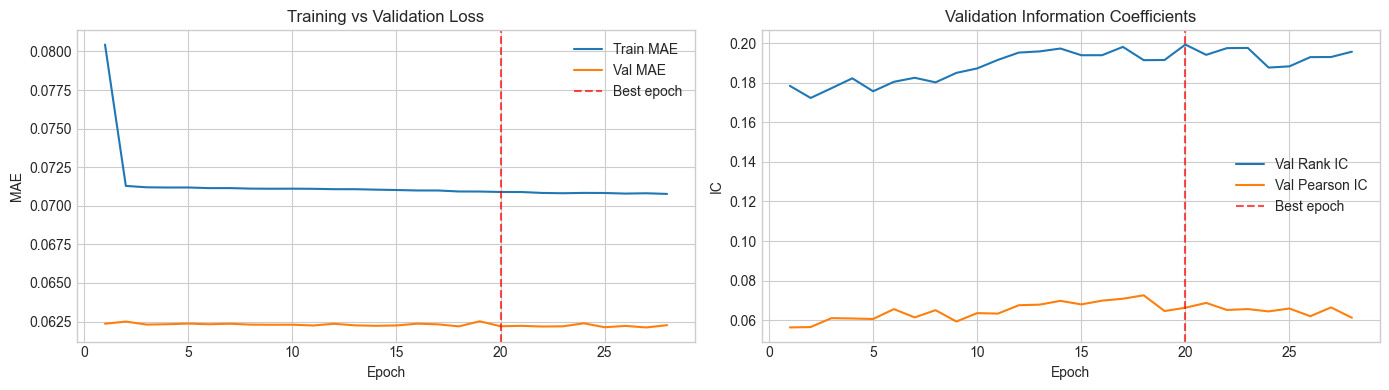

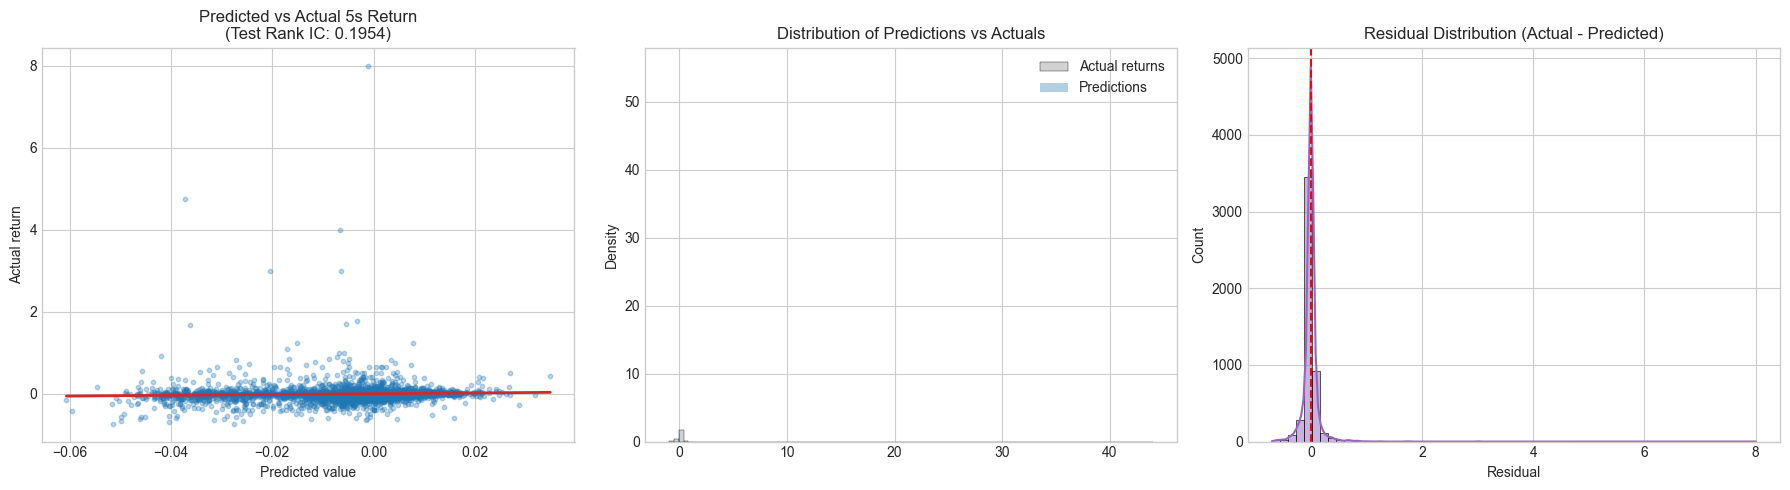

In [23]:
# ==========================================
# 11. Diagnostics
# ==========================================
history_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history_df.index + 1, history_df["train_loss"], label="Train MAE")
axes[0].plot(history_df.index + 1, history_df["val_loss"], label="Val MAE")
if best_epoch > 0:
    axes[0].axvline(best_epoch, color="red", linestyle="--", alpha=0.7, label="Best epoch")
axes[0].set_title("Training vs Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MAE")
axes[0].legend()

axes[1].plot(history_df.index + 1, history_df["val_rank_ic"], label="Val Rank IC")
axes[1].plot(history_df.index + 1, history_df["val_pearson_ic"], label="Val Pearson IC")
if best_epoch > 0:
    axes[1].axvline(best_epoch, color="red", linestyle="--", alpha=0.7, label="Best epoch")
axes[1].set_title("Validation Information Coefficients")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("IC")
axes[1].legend()

plt.tight_layout()
plt.show()

sample_size = min(5000, len(test_preds))
sample_idx = np.random.choice(len(test_preds), sample_size, replace=False)
residuals = test_targets - test_preds

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.regplot(
    x=test_preds[sample_idx],
    y=test_targets[sample_idx],
    ax=axes[0],
    scatter_kws={"alpha": 0.3, "s": 10, "color": "#1f77b4"},
    line_kws={"color": "#d62728", "linewidth": 2},
)
axes[0].set_title(f"Predicted vs Actual 5s Return\n(Test Rank IC: {test_metrics['rank_ic']:.4f})")
axes[0].set_xlabel("Predicted value")
axes[0].set_ylabel("Actual return")

sns.histplot(
    test_targets,
    bins=100,
    stat="density",
    color="gray",
    alpha=0.35,
    label="Actual returns",
    ax=axes[1],
)
sns.histplot(
    test_preds,
    bins=100,
    stat="density",
    color="#1f77b4",
    alpha=0.35,
    label="Predictions",
    ax=axes[1],
)
axes[1].set_title("Distribution of Predictions vs Actuals")
axes[1].legend()

sns.histplot(residuals[sample_idx], bins=60, kde=True, color="#9467bd", ax=axes[2])
axes[2].axvline(0.0, color="red", linestyle="--")
axes[2].set_title("Residual Distribution (Actual - Predicted)")
axes[2].set_xlabel("Residual")

plt.tight_layout()
plt.show()


Test backtest summary
total_samples: 61948
time_start: 2025-12-13 17:03:57+00:00
time_end: 2025-12-15 03:14:24+00:00
n_trades: 12390
trade_rate: 20.00%
n_long: 6195
n_short: 6195
signal_hit_rate: 57.00%
win_rate: 49.02%
gross_pnl_sum: 132.348678
trade_cost_sum: 146.113898
net_pnl_sum: -13.765220
avg_net_pnl_per_trade: -0.001111
avg_abs_prediction_traded: 0.02274317294359207
upper_threshold: 0.008203
lower_threshold: -0.022520
execution_price_non_null: 61948


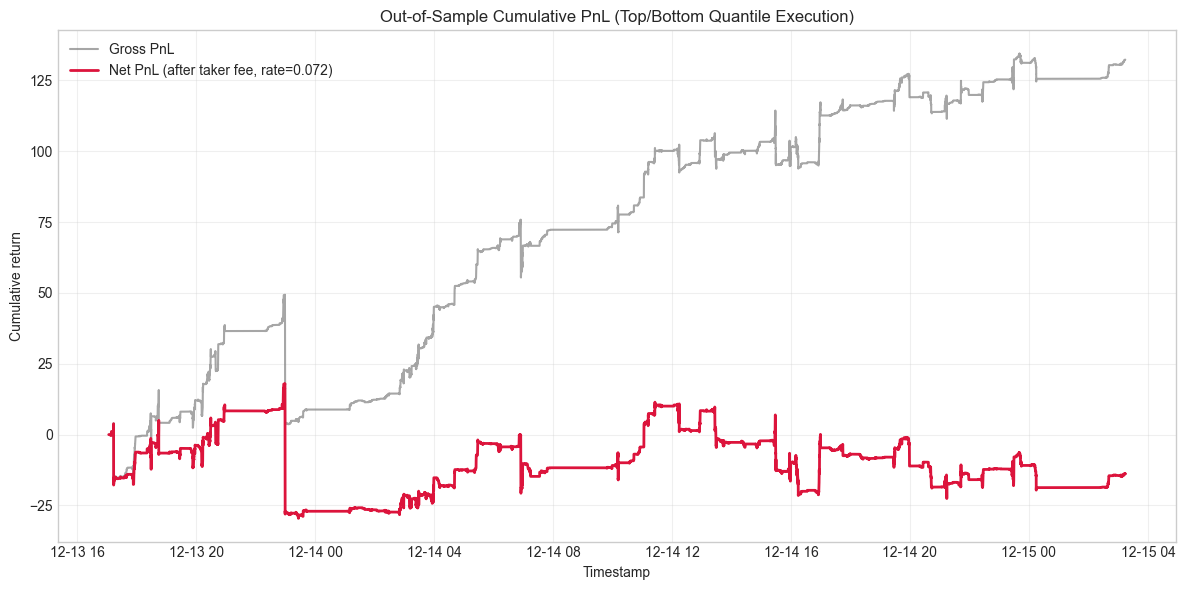

,slug,timestamp,execution_price,pred_signal,future_return,position,shares_traded,gross_pnl,trade_cost,net_pnl
13,btc-updown-15m-1765645200,2025-12-13 17:04:10+00:00,0.190,0.009383,0.026316,1,1.0,0.026316,0.011081,0.015235
19,btc-updown-15m-1765645200,2025-12-13 17:04:16+00:00,0.195,0.009287,0.000000,1,1.0,0.000000,0.011302,-0.011302
218,btc-updown-15m-1765645200,2025-12-13 17:07:35+00:00,0.065,0.008786,0.000000,1,1.0,0.000000,0.004376,-0.004376
219,btc-updown-15m-1765645200,2025-12-13 17:07:36+00:00,0.065,0.010948,-0.153846,1,1.0,-0.153846,0.004376,-0.158222
220,btc-updown-15m-1765645200,2025-12-13 17:07:37+00:00,0.065,0.010101,-0.153846,1,1.0,-0.153846,0.004376,-0.158222


In [24]:
# ==========================================
# 12. Threshold-based backtest
# Same backtest accounting and chronology checks as the updated LSTM notebook.
# ==========================================
TAKER_FEE_RATE = CONFIG["taker_fee_rate"]
UPPER_QUANTILE = CONFIG["upper_quantile"]
LOWER_QUANTILE = CONFIG["lower_quantile"]


def run_threshold_backtest(
    results_df,
    upper_quantile=0.90,
    lower_quantile=0.10,
    taker_fee_rate=0.072,
):
    bt_df = results_df.sort_values(["timestamp", "slug"]).reset_index(drop=True).copy()
    bt_df["execution_price"] = pd.to_numeric(bt_df["execution_price"], errors="coerce")

    if bt_df["execution_price"].isna().any():
        missing_count = int(bt_df["execution_price"].isna().sum())
        raise ValueError(
            f"execution_price has {missing_count} missing values. Please confirm ../data/LSTM_DATA_WITH_PRICE.parquet includes price data."
        )

    upper_threshold = bt_df["pred_signal"].quantile(upper_quantile)
    lower_threshold = bt_df["pred_signal"].quantile(lower_quantile)

    bt_df["position"] = 0
    bt_df.loc[bt_df["pred_signal"] >= upper_threshold, "position"] = 1
    bt_df.loc[bt_df["pred_signal"] <= lower_threshold, "position"] = -1

    bt_df["shares_traded"] = np.abs(bt_df["position"]).astype(float)
    bt_df["gross_pnl"] = bt_df["position"] * bt_df["future_return"]
    bt_df["trade_cost"] = (
        bt_df["shares_traded"]
        * taker_fee_rate
        * bt_df["execution_price"]
        * (1.0 - bt_df["execution_price"])
    )
    bt_df["net_pnl"] = bt_df["gross_pnl"] - bt_df["trade_cost"]

    trades_only = bt_df[bt_df["position"] != 0].copy()

    signal_hit_rate = (
        np.mean(np.sign(trades_only["pred_signal"]) == np.sign(trades_only["future_return"]))
        if len(trades_only) > 0
        else np.nan
    )
    win_rate = (trades_only["net_pnl"] > 0).mean() if len(trades_only) > 0 else np.nan

    summary = {
        "total_samples": len(bt_df),
        "time_start": bt_df["timestamp"].min(),
        "time_end": bt_df["timestamp"].max(),
        "n_trades": len(trades_only),
        "trade_rate": len(trades_only) / len(bt_df) if len(bt_df) > 0 else np.nan,
        "n_long": int((trades_only["position"] == 1).sum()),
        "n_short": int((trades_only["position"] == -1).sum()),
        "signal_hit_rate": signal_hit_rate,
        "win_rate": win_rate,
        "gross_pnl_sum": bt_df["gross_pnl"].sum(),
        "trade_cost_sum": bt_df["trade_cost"].sum(),
        "net_pnl_sum": bt_df["net_pnl"].sum(),
        "avg_net_pnl_per_trade": trades_only["net_pnl"].mean() if len(trades_only) > 0 else np.nan,
        "avg_abs_prediction_traded": (
            trades_only["pred_signal"].abs().mean() if len(trades_only) > 0 else np.nan
        ),
        "upper_threshold": upper_threshold,
        "lower_threshold": lower_threshold,
        "execution_price_non_null": int(bt_df["execution_price"].notna().sum()),
    }

    return bt_df, trades_only, summary


bt_df, trades_only, bt_summary = run_threshold_backtest(
    test_results_df,
    upper_quantile=UPPER_QUANTILE,
    lower_quantile=LOWER_QUANTILE,
    taker_fee_rate=TAKER_FEE_RATE,
)

print()
print("=" * 60)
print("Test backtest summary")
print("=" * 60)
for key, value in bt_summary.items():
    if isinstance(value, float):
        if "rate" in key or "hit" in key or "win" in key:
            print(f"{key}: {value:.2%}")
        else:
            print(f"{key}: {value:.6f}")
    else:
        print(f"{key}: {value}")

backtest_dataset = bt_df.copy()

plt.figure(figsize=(12, 6))
plt.plot(bt_df["timestamp"], bt_df["gross_pnl"].cumsum(), label="Gross PnL", color="gray", alpha=0.7)
plt.plot(
    bt_df["timestamp"],
    bt_df["net_pnl"].cumsum(),
    label=f"Net PnL (after taker fee, rate={TAKER_FEE_RATE})",
    color="crimson",
    linewidth=2,
)
plt.title("Out-of-Sample Cumulative PnL (Top/Bottom Quantile Execution)")
plt.xlabel("Timestamp")
plt.ylabel("Cumulative return")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

trades_only.head()
